# Logistic Regression with PCA

In this notebook we will study the [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) model on our dataset by first applying a [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to it.

In [1]:
#Importing libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

#Libraries for preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
# Libraries for modeling
from sklearn.linear_model import LogisticRegression
#Libraries for evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, auc, roc_curve, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from itertools import cycle
#Libraries for saving the model
import joblib
import os
from sklearn.pipeline import Pipeline

## Pre-processing

In [2]:
data = pd.read_csv('../data/rt_iot2022.csv')
data.head()

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502,MQTT_Publish


As seen in the data analysis, we have two categorical features. We are going to encode th categories using a [OneHot Encoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

In [3]:
categorical_feature = ['proto', 'service']
onehot = OneHotEncoder(sparse_output = False)
encoded_categorical = onehot.fit_transform(data[categorical_feature])

encoded_df = pd.DataFrame(encoded_categorical, columns = onehot.get_feature_names_out(categorical_feature))
data_encoded = data.drop(categorical_feature, axis = 1)
data_encoded = pd.concat([data_encoded, encoded_df], axis = 1)
data_encoded.head()

,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,service_-,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl
0,38667,1883,32.011598,9,5,3,3,0.281148,0.156193,0.437341,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,51143,1883,31.883584,9,5,3,3,0.282277,0.156821,0.439097,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,44761,1883,32.124053,9,5,3,3,0.280164,0.155647,0.435811,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,60893,1883,31.961063,9,5,3,3,0.281593,0.156440,0.438033,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,51087,1883,31.902362,9,5,3,3,0.282111,0.156728,0.438839,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


We then separate the target from the dataset and split those two datasets in traing and testing sets.

In [4]:
# split the data into features and target
X = data_encoded.drop('Attack_type', axis=1)
y = data_encoded['Attack_type']
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

To ensure that our model behave correctly we standardize the data using [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## PCA and model traning

We apply the PCA in order to keep only 10 components (nearly 10% of features).  

Then we apply the Logistic Regression model with a maximum of iteration set to 1000. It will enable future optimization algorithms to run longer and get a better result.

In [6]:
model = LogisticRegression(max_iter = 1000)
pca = PCA(n_components = 10)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model.fit(X_train_pca, y_train)
y_pred = model.predict(X_test_pca)

## Evaluation of the model

As the model is really well cleaned and has a good amount of data we expect a good result on our model.

In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.977, Precision: 0.977, Recall: 0.977, F1: 0.976


Indeed the result are very good ! Let's see the classification report for more detail.

In [8]:
print(classification_report(y_test, y_pred))

c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                            precision    recall  f1-score   support

            ARP_poisioning       0.92      0.76      0.83      2325
            DDOS_Slowloris       0.77      0.73      0.75       160
             DOS_SYN_Hping       1.00      1.00      1.00     28398
              MQTT_Publish       1.00      0.99      1.00      1244
Metasploit_Brute_Force_SSH       0.00      0.00      0.00        11
             NMAP_FIN_SCAN       0.00      0.00      0.00         8
         NMAP_OS_DETECTION       0.99      1.00      0.99       600
             NMAP_TCP_scan       0.98      1.00      0.99       301
             NMAP_UDP_SCAN       0.88      0.98      0.93       777
       NMAP_XMAS_TREE_SCAN       1.00      0.99      0.99       603
               Thing_Speak       0.82      0.94      0.88      2433
                Wipro_bulb       0.61      0.22      0.33        76

                  accuracy                           0.98     36936
                 macro avg       0.75      0.7

c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


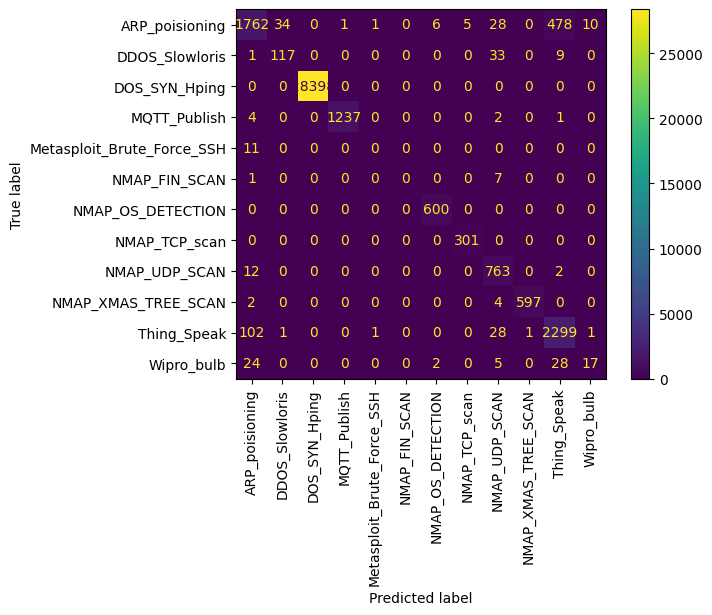

In [9]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred), display_labels=model.classes_)
disp.plot(xticks_rotation=90)
plt.show()

Our model is pretty good in almost all attack categories. He is very very good at detecting : 
- Denied of Service attack using Hping tool, 
- Attaks that use enormous amounts of MQTT Publish packets,
- OS detection using nmap that enable an attacker to tailor his attack techniques for a specific OS,
- Open TCP or UDP port discovery to expose critical services.

But our model is not good at detecting :
- Attacks on Wipro lightbulb to expose wi-fi network (33% detection),
- Open port using FIN flag with Nmap (0% detection),
- Brute force attacks on SSH using Metasploit (0% detection).

With the confusion matrix we can also say that our rate of false positive is greater than the rate of false negative. Indeed in our problem we better have false alarms (false positive) than miss an attack (false negative).

To analyse further our model we are going to analyse the Receiver Operating Characteristic (ROC) curve and Area Under Curve (AUC) score. 

In [9]:
y_pred_proba = model.predict_proba(X_test_pca)
roc_auc_micro = roc_auc_score(y_test, y_pred_proba, average='micro', multi_class='ovr')
roc_auc_macro = roc_auc_score(y_test, y_pred_proba, average='macro', multi_class='ovr')

print(f"Micro-Average ROC AUC: {roc_auc_micro:.4f}")
print(f"Macro-Average ROC AUC: {roc_auc_macro:.4f}")

Micro-Average ROC AUC: 0.9993
Macro-Average ROC AUC: 0.9880


The micro ROC compute the metrics considering each label and the macro ROC find their unweighted mean. 
Here we can say that our model is nearly perfect from the micro ROC curve.  

For deeper analysis we are going to plot ROC curve for micro, macro and for each attack.

In [10]:
n_classes = len(model.classes_)
y_test_binarized = label_binarize(y_test, classes=model.classes_)

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC for each individual class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calculate Micro-Average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Calculate Macro-Average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print(f"Metrics Calculated: Micro-AUC={roc_auc['micro']:.4f}, Macro-AUC={roc_auc['macro']:.4f}")

Metrics Calculated: Micro-AUC=0.9993, Macro-AUC=0.9880


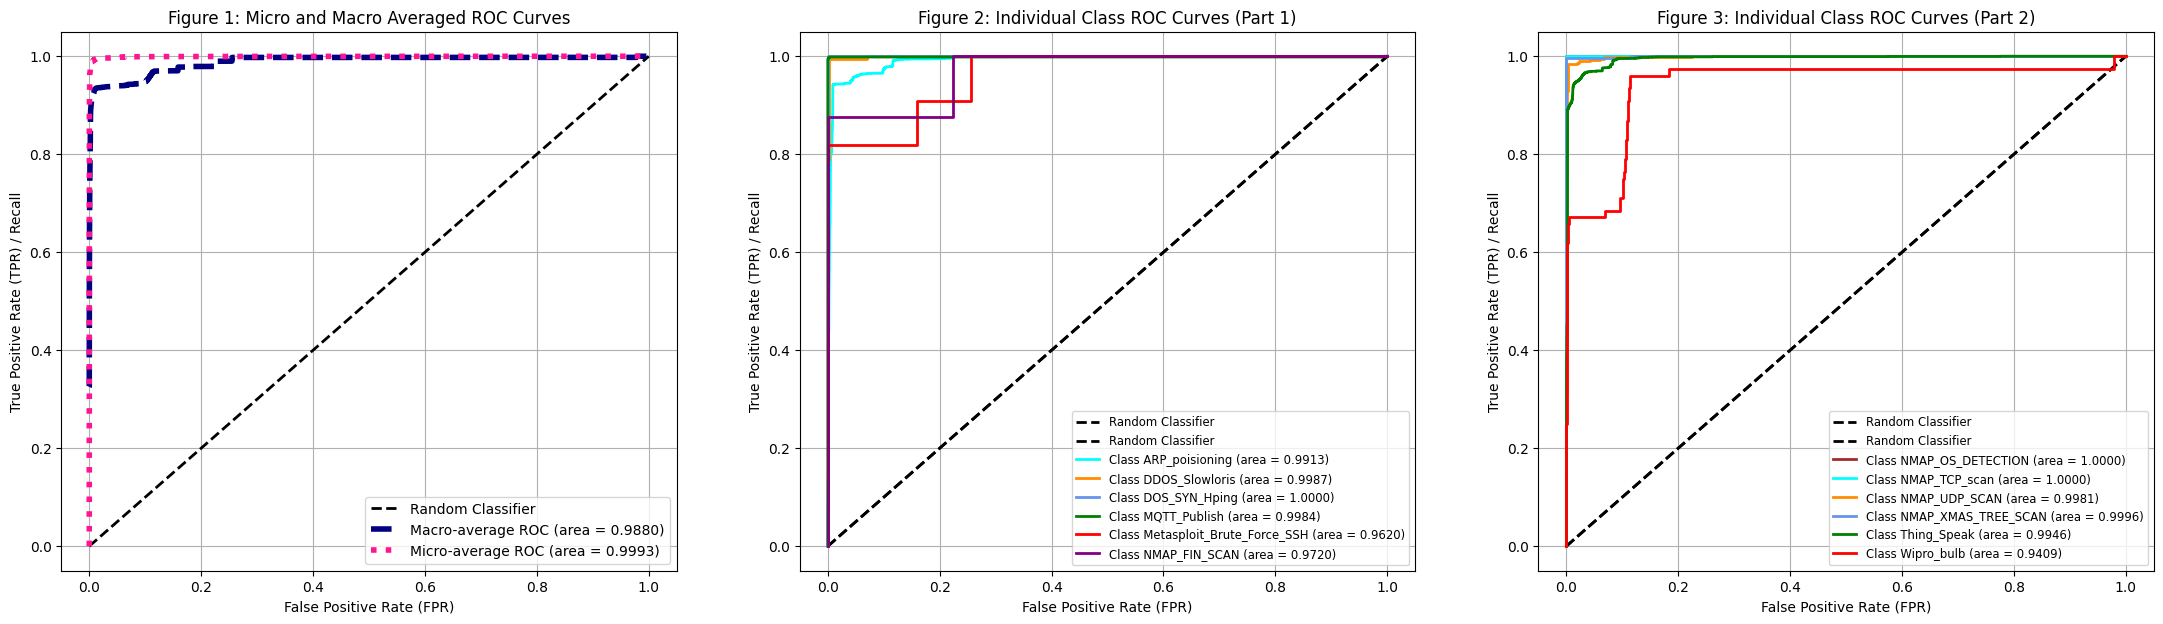

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(27, 7)) # Adjust figure size as desired

# Plot the diagonal line
for ax in axs:
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

# Plot the Macro-average curve
axs[0].plot(
    fpr["macro"],
    tpr["macro"],
    label=f'Macro-average ROC (area = {roc_auc["macro"]:.4f})',
    color='navy',
    linestyle='--',
    linewidth=4,
)

# Plot the Micro-average curve
axs[0].plot(
    fpr["micro"],
    tpr["micro"],
    label=f'Micro-average ROC (area = {roc_auc["micro"]:.4f})',
    color='deeppink',
    linestyle=':',
    linewidth=4,
)

axs[0].set(xlabel = 'False Positive Rate (FPR)', ylabel ='True Positive Rate (TPR) / Recall')
axs[0].set_title('Figure 1: Micro and Macro Averaged ROC Curves')
axs[0].legend(loc="lower right")
axs[0].grid(True)


# Split the classes into two halves for plotting on separate figures
mid_point = n_classes // 2
class_indices_1 = range(mid_point)
class_indices_2 = range(mid_point, n_classes)

# Define a color cycle for the individual plots
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])


def plot_individual_curves(indices, fig_num, title_suffix, ax: plt.Axes):
    """Helper function to plot individual ROC curves."""
    
    # Plot the diagonal line
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

    for i in indices:
        color = next(colors)
        ax.plot(
            fpr[i],
            tpr[i],
            color=color,
            lw=2,
            label=f'Class {model.classes_[i]} (area = {roc_auc[i]:.4f})',
        )
    ax.set(xlabel = 'False Positive Rate (FPR)', ylabel='True Positive Rate (TPR) / Recall')
    ax.set_title(f'Figure {fig_num}: Individual Class ROC Curves ({title_suffix})')
    ax.legend(loc="lower right", fontsize='small')
    ax.grid(True)


# Plot Figure 2 (First Half)
if len(class_indices_1) > 0:
    plot_individual_curves(class_indices_1, 2, 'Part 1', axs[1])

# Plot Figure 3 (Second Half)
if len(class_indices_2) > 0:
    plot_individual_curves(class_indices_2, 3, 'Part 2', axs[2])
    
plt.show()

With the first figure we can clearly see the drawback for having an imbalaced data : we have a nearly perfect micro average curve but the macro average curve displays more false negative due to the imbalanced dataset.

In the second and third figure we can clearly see the 3 attacks that our model have some difficulty to classify : *Metasploit_Brute_Force_SSH*, *NMAP_FIN_SCAN* and *Wipro_bulb*.

## Export of model and pre-processing pipeline

To facilitate the optimization work of this model we will export both the model and the pre-processing pipeline.

In [ ]:
JOB_DIR = '../jobs'

# Define the filename for your saved model
preprocessing_filename = 'preprocessing.joblib'
PP_PATH = os.path.join(JOB_DIR, preprocessing_filename)

pipeline_steps = [
    ('scaler', scaler),
    ('pca', pca),
]

preprocessing_pipeline = Pipeline(pipeline_steps)

# --- The Export Step ---
try:
    joblib.dump(preprocessing_pipeline, os.path.abspath(PP_PATH))
    print(f"Pipeline successfully exported to: {PP_PATH}")
except Exception as e:
    print(f"An error occurred during export: {e}")

Pipeline successfully exported to: ../jobs\preprocessing.joblib


In [14]:
model_filename = 'logistic_regression_PCA_model.joblib'
MODEL_PATH = os.path.join(JOB_DIR, model_filename)
try:
    joblib.dump(model, MODEL_PATH)
    print(f"Model successfully exported to: {MODEL_PATH}")
except Exception as e:
    print(f"An error occurred during export: {e}")

Model successfully exported to: ../jobs\logistic_regression_PCA_model.joblib
